In [47]:
import numpy as np
import matplotlib.pyplot as plt

In [67]:
# generating simple binary classification data
np.random.seed(0)
num_samples = 100
data = np.random.randn(num_samples, 2)
true_labels = (data[:, 0] + data[:, 1] > 0).astype(int)
true_labels = true_labels.reshape(-1, 1)  # Reshape to (num_samples, 1)

data_test = np.random.randn(20, 2)
true_labels_test = (data_test[:, 0] + data_test[:, 1] > 0).astype(int)
true_labels_test = true_labels_test.reshape(-1, 1)



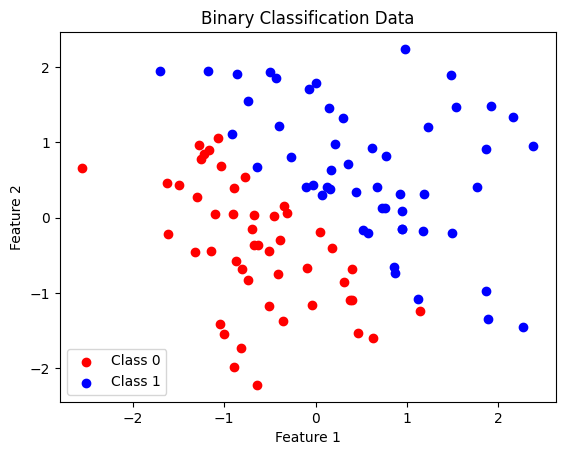

In [50]:
# make sure labels are a 1D array for boolean indexing
labels = true_labels.ravel()
mask0 = labels == 0
mask1 = labels == 1

plt.scatter(data[mask0, 0], data[mask0, 1], color='red', label='Class 0')
plt.scatter(data[mask1, 0], data[mask1, 1], color='blue', label='Class 1')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Binary Classification Data')
plt.legend()
plt.show()

In [51]:
def initialize_parameters(n_features):
    w = np.random.randn(n_features, 1)
    b = np.random.randn(1)
    return w, b

def sigmoid(z):
    return 1 / (1 + np.exp(-z))


w, b = initialize_parameters(2)
print(w)
print(b)


[[-0.36918184]
 [-0.23937918]]
[1.0996596]


In [56]:
def forward(data, w, b):
    z = np.dot(data, w) + b
    pred_labels = sigmoid(z)
    return pred_labels

# binary cross-entropy loss function
def compute_loss(true_labels, pred_labels):
    return -(true_labels * np.log(pred_labels) + (1 - true_labels) * np.log(1 - pred_labels))

def backward(data, true_labels, pred_labels):
    dl_dz = pred_labels - true_labels
    grad_w = data.T @ dl_dz / len(data)
    grad_b = np.mean(dl_dz)
    return grad_w, grad_b

def update_parameters(learning_rate, w, b, grad_w, grad_b):
    w -= learning_rate * grad_w
    b -= learning_rate * grad_b
    return w, b

pred_labels = forward(data, w, b)
loss = compute_loss(true_labels, pred_labels)
grad_w, grad_b = backward(data, true_labels, pred_labels)
w, b = update_parameters(0.01, w, b, grad_w, grad_b)


In [68]:
def train(data, true_labels, learning_rate=0.01, num_epochs=1000):
    n_samples, n_features = data.shape
    w, b = initialize_parameters(n_features)
    
    for epoch in range(num_epochs):
        # Forward pass
        pred_labels = forward(data, w, b)
        
        # Compute loss
        loss = compute_loss(true_labels, pred_labels)
        
        # Backward pass (gradient computation)
        grad_w, grad_b = backward(data, true_labels, pred_labels)
        
        # Update parameters
        w, b = update_parameters(learning_rate, w, b, grad_w, grad_b)

        if epoch % 100 == 0:
            print(f'Epoch {epoch}, Loss: {np.mean(loss)}')
    
    print(f'Final Loss: {np.mean(loss)}')
    print(f'Final weights: {w}')
    print(f'Final bias: {b}')
    return w, b

def predict(data_test, w, b):
    pred_probs = forward(data_test, w, b)
    return (pred_probs > 0.5).astype(int)

w, b = train(data, true_labels, learning_rate=0.01, num_epochs=1000)
predicted_labels = predict(data_test, w, b)
accuracy = np.mean(predicted_labels == true_labels_test)
print(f'Accuracy: {accuracy}')

Epoch 0, Loss: 1.0670824293398864
Epoch 100, Loss: 0.7933782657370136
Epoch 200, Loss: 0.6240956075650024
Epoch 300, Loss: 0.5214789407525362
Epoch 400, Loss: 0.4551035490782171
Epoch 500, Loss: 0.40876598879408943
Epoch 600, Loss: 0.3743609238310041
Epoch 700, Loss: 0.3476051697851418
Epoch 800, Loss: 0.32606023114234456
Epoch 900, Loss: 0.30824060281036186
Final Loss: 0.29332777323678655
Final weights: [[1.29533433]
 [1.14351827]]
Final bias: [0.00265264]
Accuracy: 0.95


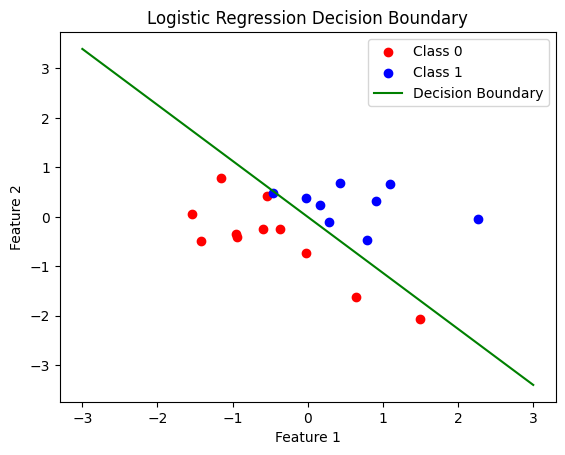

In [69]:
# plot the decision boundary based on data_test
x_values = np.linspace(-3, 3, 100)
y_values = -(w[0] * x_values + b) / w[1]
plt.scatter(data_test[true_labels_test[:, 0] == 0, 0], data_test[true_labels_test[:, 0] == 0, 1], color='red', label='Class 0')
plt.scatter(data_test[true_labels_test[:, 0] == 1, 0], data_test[true_labels_test[:, 0] == 1, 1], color='blue', label='Class 1')
plt.plot(x_values, y_values, color='green', label='Decision Boundary')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Logistic Regression Decision Boundary')
plt.legend()
plt.show()
